# Urban Air Forecast Network (UAFN)
## Air Quality Forecasting Using Graph Neural Networks

**Course**: Project: Computer Science Project (CSEMCSPCSP01)  
**Phase 2**: Development Phase  

This notebook implements the complete UAFN pipeline:
1. Synthetic data generation (simulating EEA monitoring stations)
2. Spatial graph construction using k-NN
3. GNN model implementation (GCN, GraphSAGE) with GRU temporal encoding
4. Training and evaluation
5. Visualization of results

---

## 1. Setup and Imports

In [3]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 15.1 MB/s eta 0:00:00


In [4]:
# Install required packages (uncomment if needed)
# !pip install torch torchvision torch-geometric matplotlib seaborn networkx pandas scikit-learn

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
from scipy.spatial.distance import cdist
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv
from torch_geometric.data import Data

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Plot settings
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'serif'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {device}')

PyTorch: 2.10.0+cpu
Device: cpu


## 2. Synthetic Data Generation

We simulate data from 10 air quality monitoring stations with the following properties:
- **Diurnal cycles**: Pollution peaks during daytime (traffic hours)
- **Weekly patterns**: Lower pollution on weekends
- **Spatial correlation**: Nearby stations share common pollution trends
- **Missing values**: ~5% random gaps (sensor downtime)
- **Pollutants**: PM2.5, NO2, O3
- **Meteorological co-variates**: Temperature, wind speed, humidity

In [6]:
# Configuration
NUM_STATIONS = 10
HOURS = 360           # 15 days of hourly data
POLLUTANTS = ['PM2.5', 'NO2', 'O3']

# Station coordinates (simulating a European city monitoring network)
# Centered around Munich, Germany (lat~48.1, lon~11.5)
station_coords = {
    f'ST_{i:02d}': (
        48.1 + np.random.uniform(-0.15, 0.15),
        11.5 + np.random.uniform(-0.2, 0.2)
    ) for i in range(NUM_STATIONS)
}

station_names = list(station_coords.keys())
coords = np.array(list(station_coords.values()))

print(f'Number of stations: {NUM_STATIONS}')
print(f'Time span: {HOURS} hours ({HOURS/24:.0f} days)')
print(f'\nStation coordinates:')
for name, (lat, lon) in station_coords.items():
    print(f'  {name}: lat={lat:.4f}, lon={lon:.4f}')

Number of stations: 10
Time span: 360 hours (15 days)

Station coordinates:
  ST_00: lat=48.0624, lon=11.6803
  ST_01: lat=48.1696, lon=11.5395
  ST_02: lat=47.9968, lon=11.3624
  ST_03: lat=47.9674, lon=11.6465
  ST_04: lat=48.1303, lon=11.5832
  ST_05: lat=47.9562, lon=11.6880
  ST_06: lat=48.1997, lon=11.3849
  ST_07: lat=48.0045, lon=11.3734
  ST_08: lat=48.0413, lon=11.5099
  ST_09: lat=48.0796, lon=11.4165


In [7]:
def generate_aq_data(n_stations, n_hours, pollutant):
    """Generate spatially-correlated air quality time series.

    Each station's signal is composed of:
    - A shared regional trend (simulating weather-driven changes)
    - Station-specific diurnal cycle (traffic, heating patterns)
    - Weekly periodicity (weekday vs weekend)
    - Random noise
    """
    t = np.arange(n_hours)
    base_diurnal = np.sin(2 * np.pi * t / 24)
    base_weekly = 0.3 * np.sin(2 * np.pi * t / 168)

    # Pollutant-specific baseline statistics
    stats = {
        'PM2.5': (25, 12),  # mean, std in ug/m3
        'NO2': (35, 15),
        'O3': (50, 20)
    }
    mean, std = stats[pollutant]

    # Shared regional trend (correlated across stations)
    shared_trend = np.cumsum(np.random.randn(n_hours) * 0.3)
    shared_trend = (shared_trend - shared_trend.mean()) / (shared_trend.std() + 1e-8) * std * 0.3

    data = np.zeros((n_hours, n_stations))
    for j in range(n_stations):
        phase = np.random.uniform(0, 2)
        amplitude = np.random.uniform(0.6, 1.4)
        noise = np.random.randn(n_hours) * std * 0.2
        local_diurnal = amplitude * base_diurnal * std * 0.4
        data[:, j] = mean + local_diurnal + base_weekly * std + shared_trend + noise

    data = np.clip(data, 0, None)  # Concentrations can't be negative

    # Introduce ~5% missing values (simulating sensor downtime)
    mask = np.random.random(data.shape) < 0.05
    data[mask] = np.nan

    return data

# Generate data for all pollutants
aq_data = {}
for pol in POLLUTANTS:
    aq_data[pol] = generate_aq_data(NUM_STATIONS, HOURS, pol)
    missing_pct = np.isnan(aq_data[pol]).mean() * 100
    print(f'{pol}: shape={aq_data[pol].shape}, missing={missing_pct:.1f}%')

# Generate meteorological co-variates
t = np.arange(HOURS)
temperature = 15 + 8 * np.sin(2 * np.pi * t / 24 - np.pi/2) + np.random.randn(HOURS) * 2
wind_speed = np.abs(5 + np.random.randn(HOURS) * 2)
humidity = np.clip(60 + 15 * np.sin(2 * np.pi * t / 24) + np.random.randn(HOURS) * 5, 20, 100)

print(f'\nMeteo features: temperature, wind_speed, humidity ({HOURS} hours each)')

PM2.5: shape=(360, 10), missing=4.9%
NO2: shape=(360, 10), missing=5.3%
O3: shape=(360, 10), missing=4.4%

Meteo features: temperature, wind_speed, humidity (360 hours each)


## 3. Exploratory Data Analysis

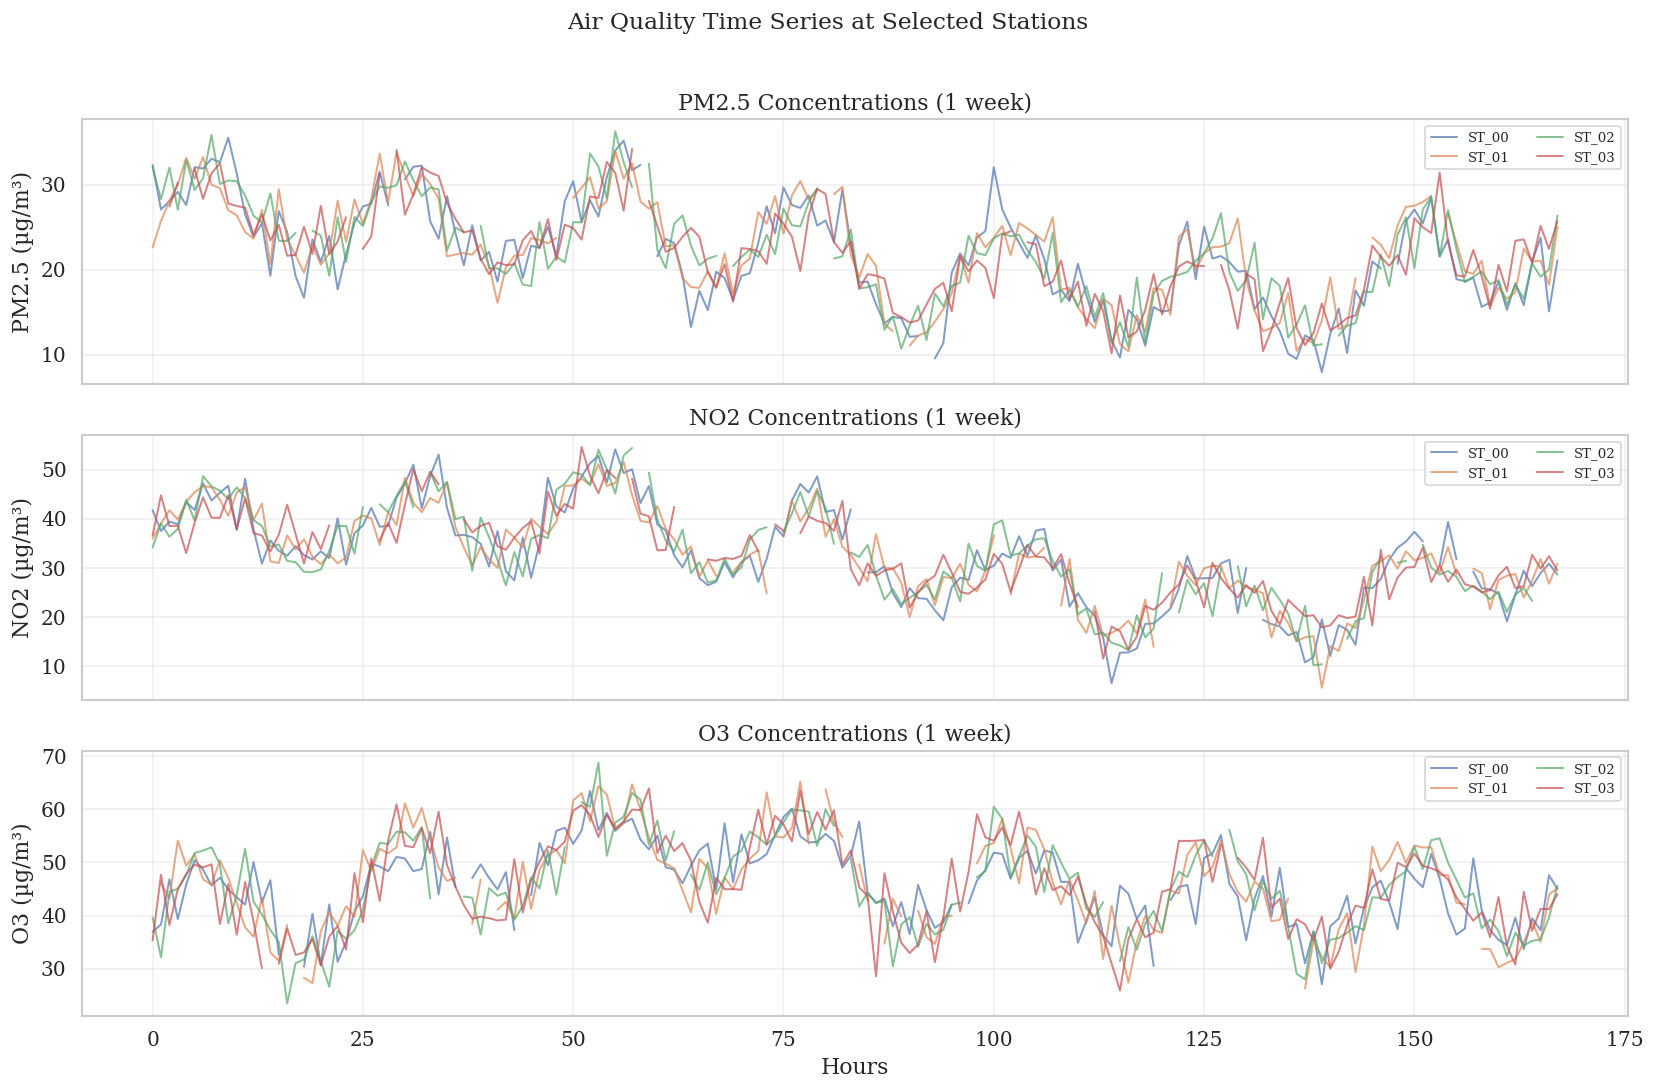

In [8]:
# Plot time series for each pollutant
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
hours_to_show = 168  # 1 week

for idx, (pol, ax) in enumerate(zip(POLLUTANTS, axes)):
    for st in range(min(4, NUM_STATIONS)):
        ax.plot(range(hours_to_show), aq_data[pol][:hours_to_show, st],
                alpha=0.7, linewidth=1.2, label=station_names[st])
    ax.set_ylabel(f'{pol} (\u00b5g/m\u00b3)')
    ax.set_title(f'{pol} Concentrations (1 week)')
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Hours')
plt.suptitle('Air Quality Time Series at Selected Stations', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

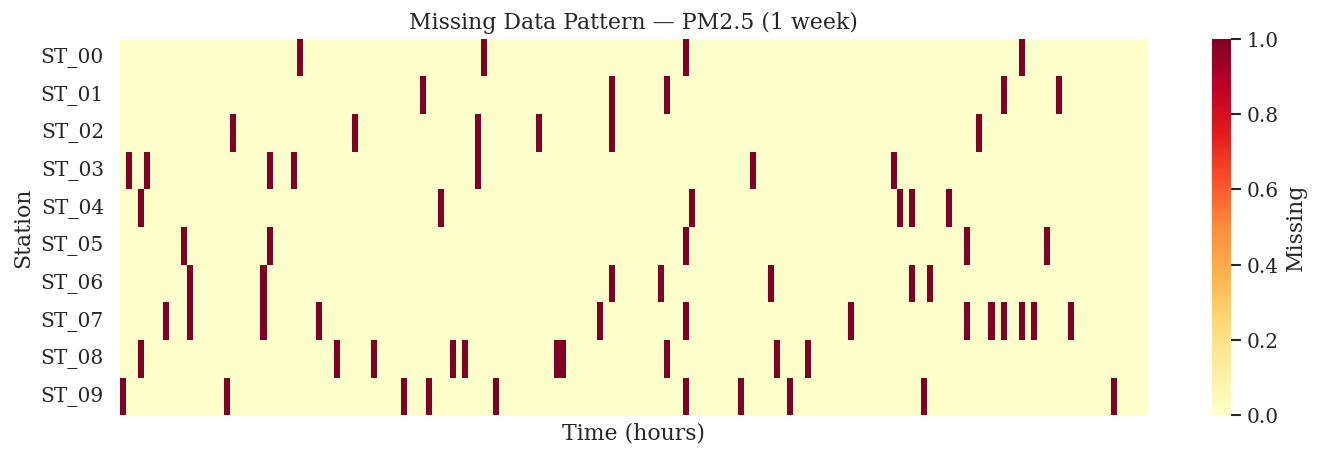

In [9]:
# Missing data visualization
fig, ax = plt.subplots(figsize=(12, 4))
missing = np.isnan(aq_data['PM2.5'][:168, :]).astype(float)
sns.heatmap(missing.T, cmap='YlOrRd', cbar_kws={'label': 'Missing'}, ax=ax,
            yticklabels=station_names, xticklabels=False)
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Station')
ax.set_title('Missing Data Pattern \u2014 PM2.5 (1 week)')
plt.tight_layout()
plt.show()

In [10]:
# Compute descriptive statistics
for pol in POLLUTANTS:
    df = pd.DataFrame(aq_data[pol], columns=station_names)
    print(f'\n=== {pol} Statistics (\u00b5g/m\u00b3) ===')
    print(df.describe().round(2).to_string())


=== PM2.5 Statistics (µg/m³) ===
        ST_00   ST_01   ST_02   ST_03   ST_04   ST_05   ST_06   ST_07   ST_08   ST_09
count  349.00  342.00  350.00  339.00  346.00  346.00  339.00  338.00  340.00  335.00
mean    24.84   25.27   25.31   25.17   25.08   25.19   25.02   25.08   25.23   25.03
std      6.84    6.26    6.17    5.79    5.83    6.00    5.40    5.89    6.77    5.85
min      7.95   10.39   10.70   10.16   10.95   10.96   11.94    7.47    4.64    8.48
25%     19.75   21.31   20.77   21.33   21.02   20.98   21.19   20.87   20.62   21.26
50%     25.03   25.22   25.54   25.06   25.42   25.30   25.26   25.53   25.22   25.10
75%     29.88   29.71   29.92   29.47   28.80   29.43   28.69   29.12   30.66   29.31
max     40.39   39.53   39.49   38.85   39.37   40.45   40.41   38.31   39.09   38.61

=== NO2 Statistics (µg/m³) ===
        ST_00   ST_01   ST_02   ST_03   ST_04   ST_05   ST_06   ST_07   ST_08   ST_09
count  348.00  348.00  342.00  337.00  337.00  339.00  337.00  332.00  344

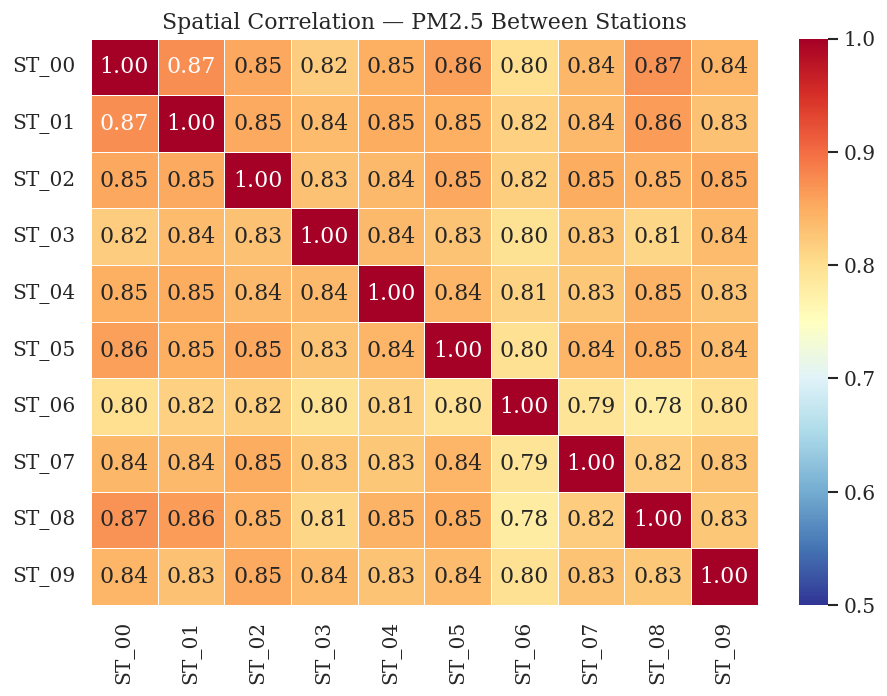

In [11]:
# Spatial correlation analysis
pm25_filled = pd.DataFrame(aq_data['PM2.5'], columns=station_names).ffill().bfill().values

fig, ax = plt.subplots(figsize=(8, 6))
corr = pd.DataFrame(pm25_filled, columns=station_names).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu_r', ax=ax,
            vmin=0.5, vmax=1.0, linewidths=0.5)
ax.set_title('Spatial Correlation \u2014 PM2.5 Between Stations')
plt.tight_layout()
plt.show()

## 4. Spatial Graph Construction

We model the monitoring network as a graph where:
- **Nodes** = monitoring stations
- **Edges** = k-nearest neighbour connections based on geographic distance
- **Edge weights** = inverse distance ($w_{ij} = 1 / (d_{ij} + \epsilon)$)

In [12]:
# Compute pairwise distances between stations
dist_matrix = cdist(coords, coords)

# Build k-NN graph
K = 4  # number of nearest neighbours
EPSILON = 0.01

edges_src, edges_dst, edge_weights_list = [], [], []
G = nx.Graph()

for i in range(NUM_STATIONS):
    G.add_node(i, pos=(coords[i, 1], coords[i, 0]), label=station_names[i])
    neighbors = np.argsort(dist_matrix[i])[1:K+1]  # skip self
    for j in neighbors:
        w = 1.0 / (dist_matrix[i, j] + EPSILON)
        edges_src.append(i)
        edges_dst.append(j)
        edge_weights_list.append(w)
        G.add_edge(i, j, weight=min(w, 50))

edge_index = torch.tensor([edges_src, edges_dst], dtype=torch.long)
edge_weight = torch.tensor(edge_weights_list, dtype=torch.float32)

print(f'Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print(f'Edge index shape: {edge_index.shape}')
print(f'Average degree: {2 * G.number_of_edges() / G.number_of_nodes():.1f}')

Graph: 10 nodes, 25 edges
Edge index shape: torch.Size([2, 40])
Average degree: 5.0


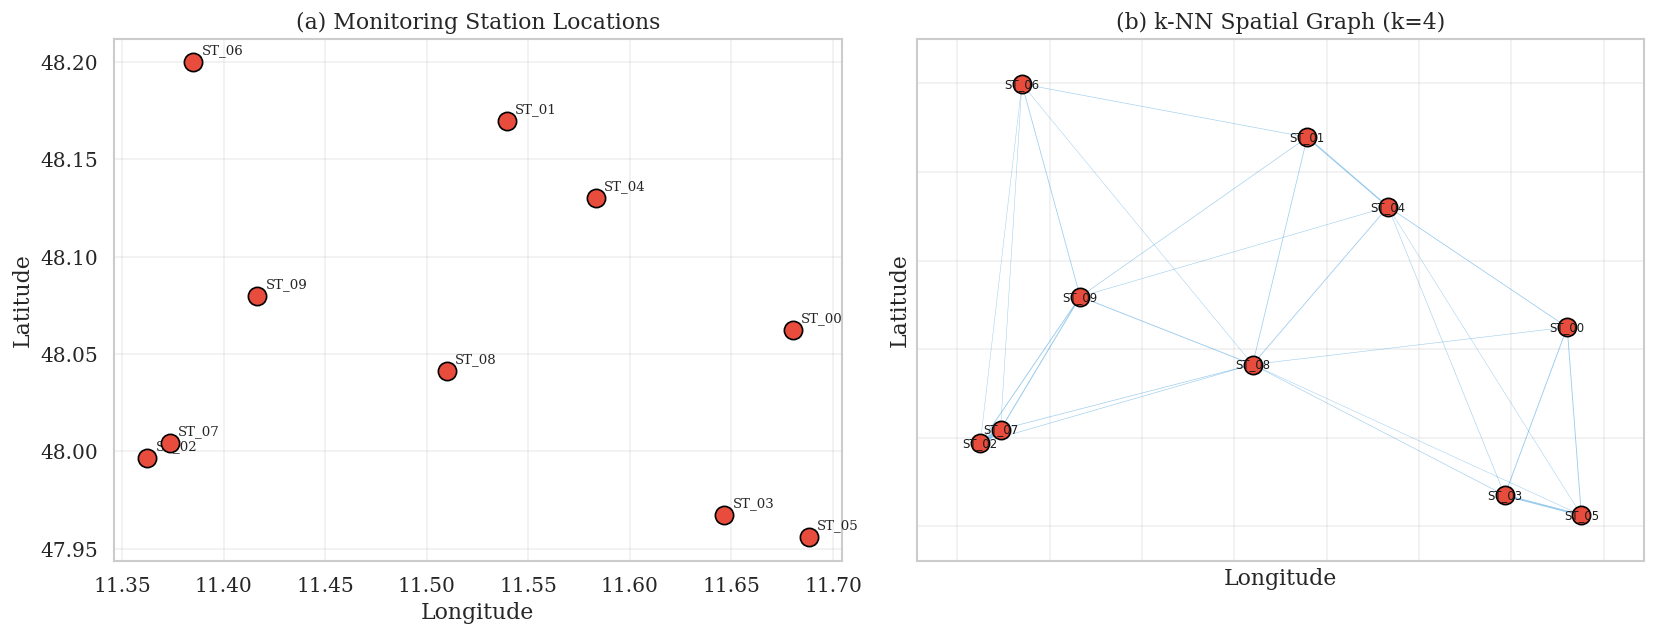

In [13]:
# Visualize the graph
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: Station locations
ax = axes[0]
ax.scatter(coords[:, 1], coords[:, 0], s=120, c='#E74C3C', edgecolors='black',
           zorder=5, linewidth=1)
for i, name in enumerate(station_names):
    ax.annotate(name, (coords[i, 1], coords[i, 0]), fontsize=8, ha='left',
                xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('(a) Monitoring Station Locations')
ax.grid(True, alpha=0.3)

# Right: k-NN graph
ax = axes[1]
pos = nx.get_node_attributes(G, 'pos')
weights = [G[u][v]['weight'] for u, v in G.edges()]
max_w = max(weights)
norm_weights = [w / max_w * 2.5 for w in weights]

nx.draw_networkx_edges(G, pos, ax=ax, width=norm_weights, alpha=0.5, edge_color='#3498DB')
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=120, node_color='#E74C3C',
                       edgecolors='black', linewidths=1)
nx.draw_networkx_labels(G, pos, ax=ax,
                        labels={i: station_names[i] for i in range(NUM_STATIONS)}, font_size=7)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'(b) k-NN Spatial Graph (k={K})')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Data Preprocessing

Steps:
1. Fill missing values (forward fill + backward fill)
2. Normalize using StandardScaler (fit on training set only)
3. Create sliding window sequences for temporal input

In [14]:
# Focus on PM2.5 for now
pm25_raw = aq_data['PM2.5'].copy()

# Fill missing values
df_pm25 = pd.DataFrame(pm25_raw, columns=station_names)
df_pm25 = df_pm25.ffill().bfill()
pm25_filled = df_pm25.values

print(f'Missing values after filling: {np.isnan(pm25_filled).sum()}')

# Normalize
scaler = StandardScaler()
pm25_norm = scaler.fit_transform(pm25_filled)

print(f'Normalized mean: {pm25_norm.mean():.4f}')
print(f'Normalized std: {pm25_norm.std():.4f}')

Missing values after filling: 0
Normalized mean: 0.0000
Normalized std: 1.0000


In [15]:
# Create sliding window sequences
WINDOW = 6    # 6 hours lookback
HORIZON = 1   # predict 1 hour ahead

def create_sequences(data, window, horizon):
    """Create (X, Y) pairs using sliding window.

    X[i] = data[i : i+window]  -> shape (stations, window)
    Y[i] = data[i+window+horizon-1]  -> shape (stations,)
    """
    X, Y = [], []
    for t in range(len(data) - window - horizon):
        X.append(data[t:t+window].T)  # (stations, window)
        Y.append(data[t+window+horizon-1])  # (stations,)
    return np.array(X), np.array(Y)

X, Y = create_sequences(pm25_norm, WINDOW, HORIZON)
print(f'Total samples: {X.shape[0]}')
print(f'X shape: {X.shape}  (samples, stations, window)')
print(f'Y shape: {Y.shape}  (samples, stations)')

Total samples: 353
X shape: (353, 10, 6)  (samples, stations, window)
Y shape: (353, 10)  (samples, stations)


In [16]:
# Train / Validation / Test split (70/15/15)
split_train = int(0.70 * len(X))
split_val = int(0.85 * len(X))

X_train, Y_train = X[:split_train], Y[:split_train]
X_val, Y_val = X[split_train:split_val], Y[split_train:split_val]
X_test, Y_test = X[split_val:], Y[split_val:]

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32).to(device)
X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
Y_val_t = torch.tensor(Y_val, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
Y_test_t = torch.tensor(Y_test, dtype=torch.float32).to(device)

edge_index_d = edge_index.to(device)
edge_weight_d = edge_weight.to(device)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

Train: 247 | Val: 53 | Test: 53


## 6. Model Definitions

### Architecture
Each model follows this pattern:
1. **GRU temporal encoder**: Processes each station's time window independently
2. **Graph convolutional layers** (GCN or GraphSAGE): Aggregate spatial information
3. **Linear prediction head**: Outputs 1-hour-ahead forecast per station

An MLP baseline (no graph structure) is included for comparison.

In [17]:
class GCN_AQ(nn.Module):
    """GCN-based air quality forecasting model.

    Architecture: GRU -> GCNConv -> GCNConv -> Linear
    """
    def __init__(self, in_channels=1, hidden_channels=32, out_channels=16):
        super().__init__()
        self.temporal = nn.GRU(in_channels, hidden_channels, batch_first=True)
        self.conv1 = GCNConv(hidden_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.fc = nn.Linear(out_channels, 1)

    def forward(self, x, edge_index, edge_weight=None):
        batch_size, n_nodes, T = x.shape

        # Temporal encoding: process each station's window
        x = x.reshape(batch_size * n_nodes, T, 1)
        _, h = self.temporal(x)
        h = h.squeeze(0).reshape(batch_size, n_nodes, -1)

        # Spatial aggregation: apply GCN per sample
        outputs = []
        for b in range(batch_size):
            hb = h[b]  # (nodes, hidden)
            hb = F.relu(self.conv1(hb, edge_index, edge_weight))
            hb = F.dropout(hb, p=0.2, training=self.training)
            hb = self.conv2(hb, edge_index, edge_weight)
            out = self.fc(hb).squeeze(-1)  # (nodes,)
            outputs.append(out)

        return torch.stack(outputs)  # (batch, nodes)


class SAGE_AQ(nn.Module):
    """GraphSAGE-based air quality forecasting model.

    Architecture: GRU -> SAGEConv -> SAGEConv -> Linear
    Uses mean aggregation for neighbourhood sampling.
    """
    def __init__(self, in_channels=1, hidden_channels=32, out_channels=16):
        super().__init__()
        self.temporal = nn.GRU(in_channels, hidden_channels, batch_first=True)
        self.conv1 = SAGEConv(hidden_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)
        self.fc = nn.Linear(out_channels, 1)

    def forward(self, x, edge_index, edge_weight=None):
        batch_size, n_nodes, T = x.shape
        x = x.reshape(batch_size * n_nodes, T, 1)
        _, h = self.temporal(x)
        h = h.squeeze(0).reshape(batch_size, n_nodes, -1)

        outputs = []
        for b in range(batch_size):
            hb = h[b]
            hb = F.relu(self.conv1(hb, edge_index))
            hb = F.dropout(hb, p=0.2, training=self.training)
            hb = self.conv2(hb, edge_index)
            out = self.fc(hb).squeeze(-1)
            outputs.append(out)

        return torch.stack(outputs)


class MLP_Baseline(nn.Module):
    """Simple MLP baseline (no graph structure)."""
    def __init__(self, window=6, n_nodes=10, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_nodes * window, hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_nodes)
        )

    def forward(self, x, edge_index=None, edge_weight=None):
        return self.net(x)


# Print model summaries
for name, model in [('GCN', GCN_AQ()), ('GraphSAGE', SAGE_AQ()),
                     ('MLP', MLP_Baseline(WINDOW, NUM_STATIONS))]:
    n_params = sum(p.numel() for p in model.parameters())
    print(f'{name}: {n_params:,} parameters')

GCN: 4,961 parameters
GraphSAGE: 6,497 parameters
MLP: 8,714 parameters


## 7. Training

In [18]:
def train_model(model, X_train, Y_train, X_val, Y_val,
                edge_index, edge_weight, epochs=40, lr=0.001,
                batch_size=64, model_name='Model'):
    """Train a model and return loss histories."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        n_batches = 0

        indices = torch.randperm(len(X_train))
        for start in range(0, len(X_train), batch_size):
            idx = indices[start:start+batch_size]
            xb = X_train[idx]
            yb = Y_train[idx]

            pred = model(xb, edge_index, edge_weight)
            loss = F.mse_loss(pred, yb)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        scheduler.step()
        avg_train_loss = epoch_loss / n_batches
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val, edge_index, edge_weight)
            val_loss = F.mse_loss(val_pred, Y_val).item()
            val_losses.append(val_loss)

        if (epoch + 1) % 10 == 0:
            print(f'  {model_name} Epoch {epoch+1:3d}: '
                  f'train_loss={avg_train_loss:.4f}, val_loss={val_loss:.4f}')

    return train_losses, val_losses

In [19]:
# Train GCN
print('=== Training GCN ===')
gcn_model = GCN_AQ(1, 32, 16)
gcn_train_loss, gcn_val_loss = train_model(
    gcn_model, X_train_t, Y_train_t, X_val_t, Y_val_t,
    edge_index_d, edge_weight_d, epochs=40, model_name='GCN'
)

=== Training GCN ===
  GCN Epoch  10: train_loss=0.3473, val_loss=0.3031
  GCN Epoch  20: train_loss=0.2771, val_loss=0.2456
  GCN Epoch  30: train_loss=0.2520, val_loss=0.2221
  GCN Epoch  40: train_loss=0.2413, val_loss=0.2195


In [20]:
# Train GraphSAGE
print('=== Training GraphSAGE ===')
sage_model = SAGE_AQ(1, 32, 16)
sage_train_loss, sage_val_loss = train_model(
    sage_model, X_train_t, Y_train_t, X_val_t, Y_val_t,
    edge_index_d, edge_weight_d, epochs=40, model_name='SAGE'
)

=== Training GraphSAGE ===
  SAGE Epoch  10: train_loss=0.2953, val_loss=0.2809
  SAGE Epoch  20: train_loss=0.2349, val_loss=0.2252
  SAGE Epoch  30: train_loss=0.2183, val_loss=0.2158
  SAGE Epoch  40: train_loss=0.2244, val_loss=0.2144


In [21]:
# Train MLP Baseline
print('=== Training MLP Baseline ===')
mlp_model = MLP_Baseline(WINDOW, NUM_STATIONS, 64)
mlp_train_loss, mlp_val_loss = train_model(
    mlp_model, X_train_t, Y_train_t, X_val_t, Y_val_t,
    edge_index_d, edge_weight_d, epochs=40, model_name='MLP'
)

=== Training MLP Baseline ===
  MLP Epoch  10: train_loss=0.3396, val_loss=0.3069
  MLP Epoch  20: train_loss=0.2140, val_loss=0.2114
  MLP Epoch  30: train_loss=0.1973, val_loss=0.2057
  MLP Epoch  40: train_loss=0.1851, val_loss=0.2038


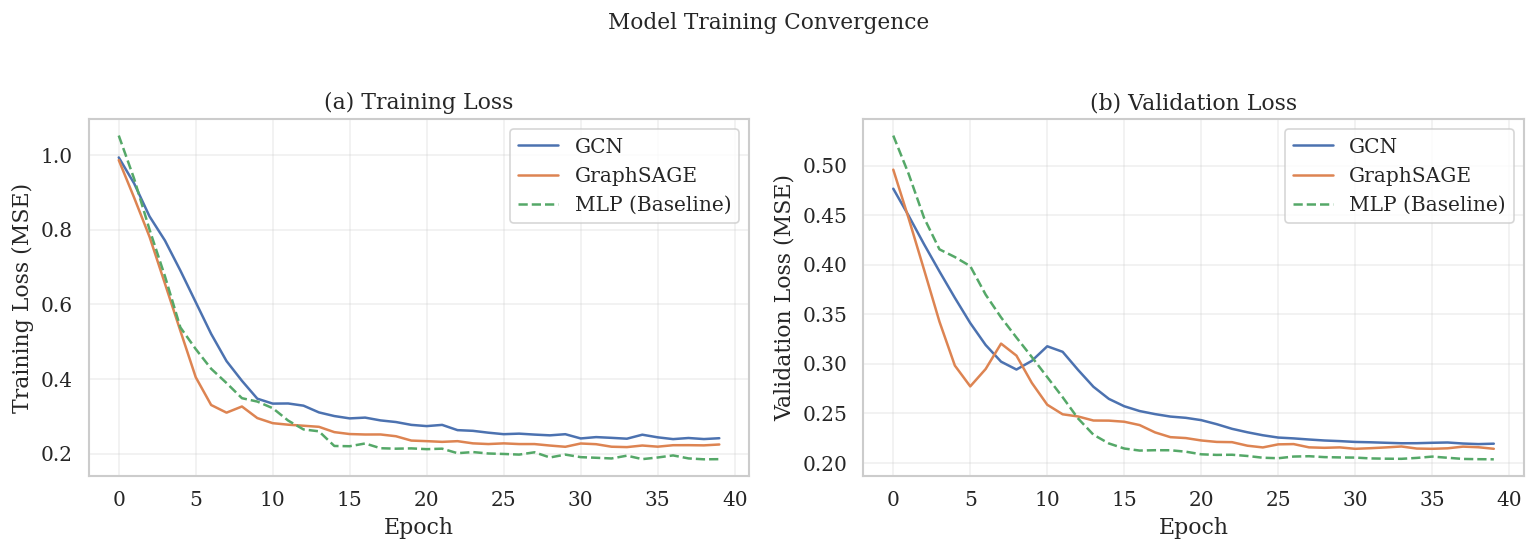

In [22]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(gcn_train_loss, label='GCN', linewidth=1.5)
ax.plot(sage_train_loss, label='GraphSAGE', linewidth=1.5)
ax.plot(mlp_train_loss, label='MLP (Baseline)', linewidth=1.5, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss (MSE)')
ax.set_title('(a) Training Loss')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(gcn_val_loss, label='GCN', linewidth=1.5)
ax.plot(sage_val_loss, label='GraphSAGE', linewidth=1.5)
ax.plot(mlp_val_loss, label='MLP (Baseline)', linewidth=1.5, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss (MSE)')
ax.set_title('(b) Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Model Training Convergence', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. Evaluation

In [23]:
def evaluate_model(model, X_test, Y_test, edge_index, edge_weight, scaler):
    """Evaluate model on test set and return real-scale metrics."""
    model.eval()
    with torch.no_grad():
        pred = model(X_test, edge_index, edge_weight).cpu().numpy()
    actual = Y_test.cpu().numpy()

    # Inverse transform to original scale (\u00b5g/m\u00b3)
    pred_real = scaler.inverse_transform(pred)
    actual_real = scaler.inverse_transform(actual)

    rmse = np.sqrt(mean_squared_error(actual_real.flatten(), pred_real.flatten()))
    mae = mean_absolute_error(actual_real.flatten(), pred_real.flatten())
    r2 = r2_score(actual_real.flatten(), pred_real.flatten())

    return pred_real, actual_real, {'RMSE': rmse, 'MAE': mae, 'R2': r2}


# Evaluate all models
gcn_pred, gcn_actual, gcn_metrics = evaluate_model(
    gcn_model, X_test_t, Y_test_t, edge_index_d, edge_weight_d, scaler)
sage_pred, sage_actual, sage_metrics = evaluate_model(
    sage_model, X_test_t, Y_test_t, edge_index_d, edge_weight_d, scaler)
mlp_pred, mlp_actual, mlp_metrics = evaluate_model(
    mlp_model, X_test_t, Y_test_t, edge_index_d, edge_weight_d, scaler)

# Display results table
results_df = pd.DataFrame({
    'Model': ['GCN', 'GraphSAGE', 'MLP (Baseline)'],
    'RMSE (\u00b5g/m\u00b3)': [gcn_metrics['RMSE'], sage_metrics['RMSE'], mlp_metrics['RMSE']],
    'MAE (\u00b5g/m\u00b3)': [gcn_metrics['MAE'], sage_metrics['MAE'], mlp_metrics['MAE']],
    'R\u00b2': [gcn_metrics['R2'], sage_metrics['R2'], mlp_metrics['R2']],
}).round(4)

print('\n' + '='*60)
print('TEST SET RESULTS: PM2.5 1-Hour Ahead Forecasting')
print('='*60)
print(results_df.to_string(index=False))
print('='*60)


TEST SET RESULTS: PM2.5 1-Hour Ahead Forecasting
         Model  RMSE (µg/m³)  MAE (µg/m³)     R²
           GCN        3.0402       2.4345 0.5395
     GraphSAGE        2.9025       2.3229 0.5803
MLP (Baseline)        2.8566       2.3015 0.5935


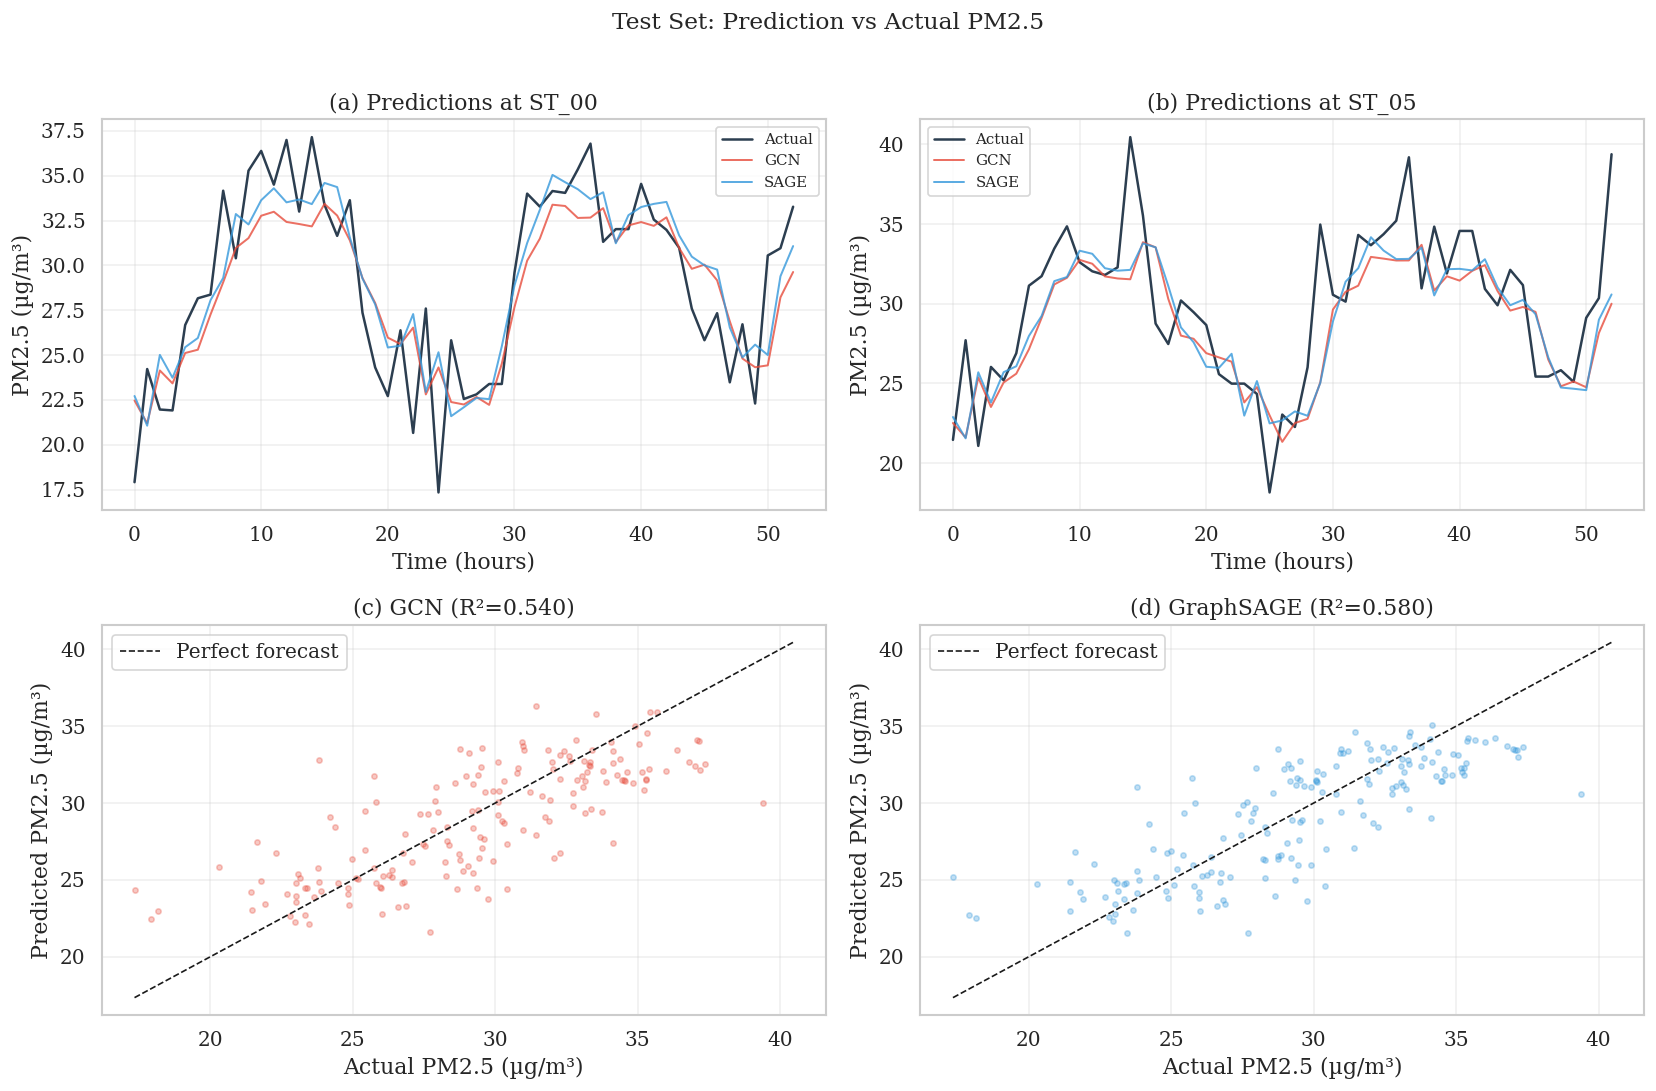

In [24]:
# Prediction vs Actual plots
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Time series at Station 0
n_show = min(120, len(gcn_pred))
t = np.arange(n_show)

ax = axes[0, 0]
ax.plot(t, gcn_actual[:n_show, 0], label='Actual', color='#2C3E50', linewidth=1.5)
ax.plot(t, gcn_pred[:n_show, 0], label='GCN', color='#E74C3C', linewidth=1.2, alpha=0.8)
ax.plot(t, sage_pred[:n_show, 0], label='SAGE', color='#3498DB', linewidth=1.2, alpha=0.8)
ax.set_xlabel('Time (hours)')
ax.set_ylabel('PM2.5 (\u00b5g/m\u00b3)')
ax.set_title(f'(a) Predictions at {station_names[0]}')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Time series at Station 5
ax = axes[0, 1]
ax.plot(t, gcn_actual[:n_show, 5], label='Actual', color='#2C3E50', linewidth=1.5)
ax.plot(t, gcn_pred[:n_show, 5], label='GCN', color='#E74C3C', linewidth=1.2, alpha=0.8)
ax.plot(t, sage_pred[:n_show, 5], label='SAGE', color='#3498DB', linewidth=1.2, alpha=0.8)
ax.set_xlabel('Time (hours)')
ax.set_ylabel('PM2.5 (\u00b5g/m\u00b3)')
ax.set_title(f'(b) Predictions at {station_names[5]}')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Scatter: GCN
ax = axes[1, 0]
ax.scatter(gcn_actual.flatten()[::3], gcn_pred.flatten()[::3], s=10, alpha=0.3, c='#E74C3C')
lim = [gcn_actual.min(), gcn_actual.max()]
ax.plot(lim, lim, 'k--', linewidth=1, label='Perfect forecast')
ax.set_xlabel('Actual PM2.5 (\u00b5g/m\u00b3)')
ax.set_ylabel('Predicted PM2.5 (\u00b5g/m\u00b3)')
ax.set_title(f'(c) GCN (R\u00b2={gcn_metrics["R2"]:.3f})')
ax.legend()
ax.grid(True, alpha=0.3)

# Scatter: GraphSAGE
ax = axes[1, 1]
ax.scatter(sage_actual.flatten()[::3], sage_pred.flatten()[::3], s=10, alpha=0.3, c='#3498DB')
ax.plot(lim, lim, 'k--', linewidth=1, label='Perfect forecast')
ax.set_xlabel('Actual PM2.5 (\u00b5g/m\u00b3)')
ax.set_ylabel('Predicted PM2.5 (\u00b5g/m\u00b3)')
ax.set_title(f'(d) GraphSAGE (R\u00b2={sage_metrics["R2"]:.3f})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Test Set: Prediction vs Actual PM2.5', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

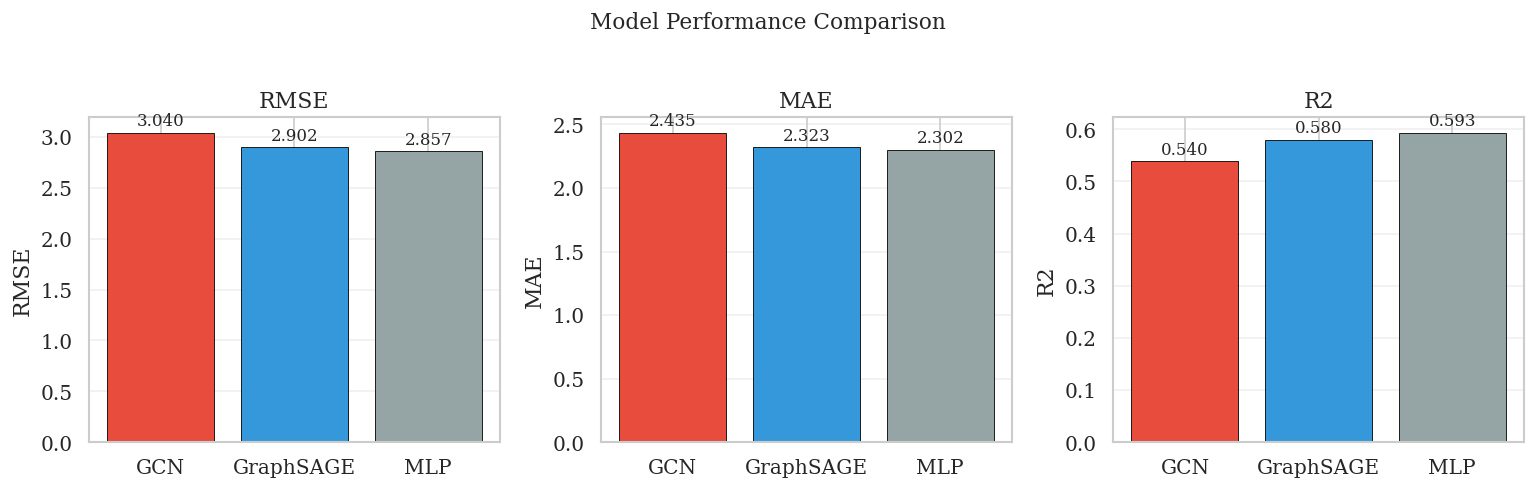

In [25]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
models = ['GCN', 'GraphSAGE', 'MLP']
all_metrics = [gcn_metrics, sage_metrics, mlp_metrics]
colors = ['#E74C3C', '#3498DB', '#95A5A6']

for idx, metric in enumerate(['RMSE', 'MAE', 'R2']):
    ax = axes[idx]
    values = [m[metric] for m in all_metrics]
    bars = ax.bar(models, values, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01 * max(values),
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Model Performance Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9. RLS Data Assimilation (Prototype)

The Recursive Least Squares filter combines sensor observations with numerical model (SILAM) predictions to produce improved estimates, especially when sensor data is missing.

In [26]:
class RLSFilter:
    """Recursive Least Squares filter for data assimilation.

    Combines observations (y_obs) with model predictions (y_model)
    to produce improved estimates, weighting each source adaptively.
    """
    def __init__(self, n_features=2, forgetting_factor=0.98):
        self.lam = forgetting_factor
        self.n = n_features
        self.w = np.zeros(n_features)  # weights
        self.P = np.eye(n_features) * 100  # inverse correlation matrix

    def update(self, x, y):
        """Update filter weights given input x and target y.

        x: array of shape (n_features,) - [observation, model_prediction]
        y: float - true value (or best available estimate)
        """
        # Gain vector
        Px = self.P @ x
        K = Px / (self.lam + x @ Px)

        # Prediction error
        e = y - self.w @ x

        # Update weights
        self.w = self.w + K * e

        # Update inverse correlation matrix
        self.P = (self.P - np.outer(K, x @ self.P)) / self.lam

        return self.w @ x  # filtered estimate

    def predict(self, x):
        return self.w @ x


# Demonstrate RLS on one station
print('=== RLS Data Assimilation Demo ===')

# Simulate: observation (with gaps) and SILAM model output (always available)
n_demo = 200
true_signal = pm25_filled[:n_demo, 0]  # ground truth
model_pred = true_signal + np.random.randn(n_demo) * 5  # noisy model
observation = true_signal + np.random.randn(n_demo) * 2  # better but with gaps

# Create gaps in observations
obs_mask = np.random.random(n_demo) > 0.15  # 15% missing
observation_gapped = observation.copy()
observation_gapped[~obs_mask] = np.nan

# Run RLS
rls = RLSFilter(n_features=2, forgetting_factor=0.98)
rls_estimates = []

for t in range(n_demo):
    if np.isnan(observation_gapped[t]):
        # No observation: use model prediction with low confidence
        x = np.array([0.0, model_pred[t]])  # zero-out missing obs
        est = rls.predict(x)
    else:
        x = np.array([observation_gapped[t], model_pred[t]])
        est = rls.update(x, true_signal[t])
    rls_estimates.append(est)

rls_estimates = np.array(rls_estimates)

# Compute errors
model_rmse = np.sqrt(mean_squared_error(true_signal, model_pred))
obs_rmse = np.sqrt(mean_squared_error(true_signal[obs_mask], observation[obs_mask]))
rls_rmse = np.sqrt(mean_squared_error(true_signal, rls_estimates))

print(f'Model-only RMSE:     {model_rmse:.3f} \u00b5g/m\u00b3')
print(f'Observation RMSE:    {obs_rmse:.3f} \u00b5g/m\u00b3 (when available)')
print(f'RLS-fused RMSE:      {rls_rmse:.3f} \u00b5g/m\u00b3')
print(f'\nRLS weights: obs={rls.w[0]:.3f}, model={rls.w[1]:.3f}')

=== RLS Data Assimilation Demo ===
Model-only RMSE:     5.133 µg/m³
Observation RMSE:    1.840 µg/m³ (when available)
RLS-fused RMSE:      8.097 µg/m³

RLS weights: obs=0.892, model=0.101


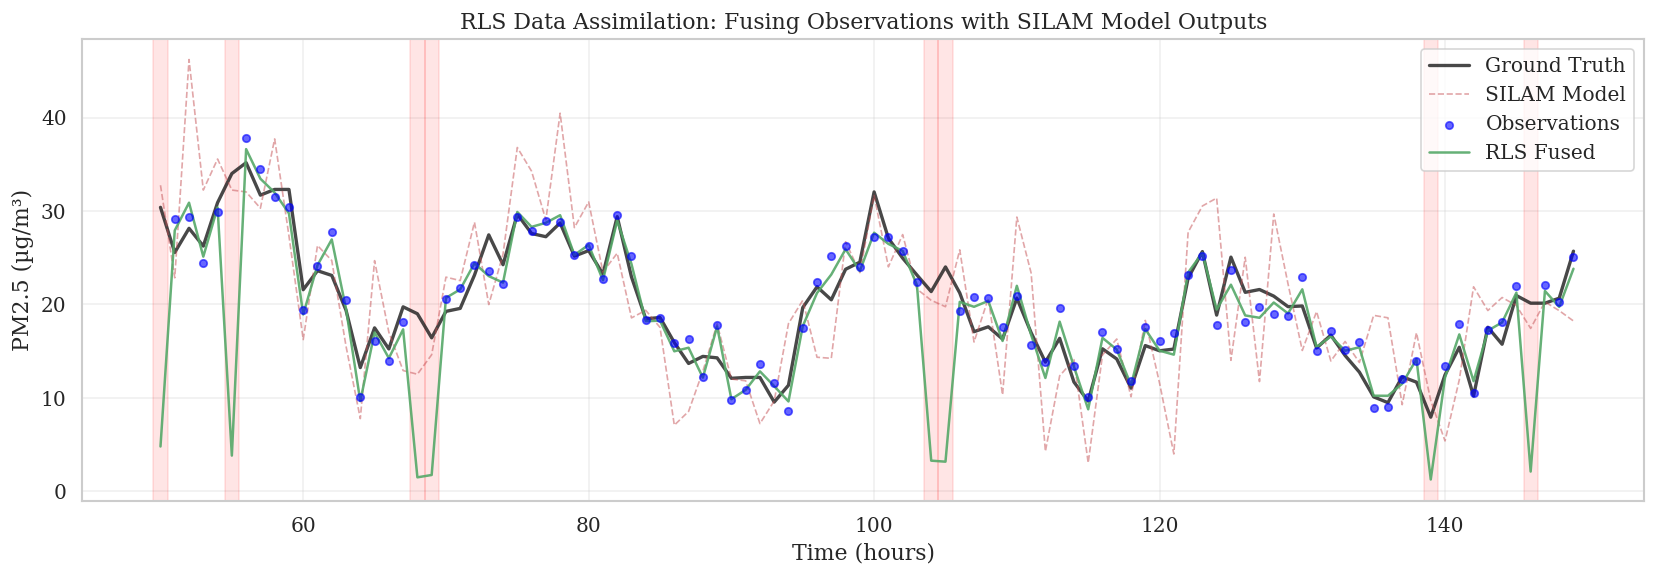

Red-shaded regions indicate missing observations.
The RLS filter smoothly fills gaps using the model prediction.


In [27]:
# Visualize RLS data assimilation
fig, ax = plt.subplots(figsize=(14, 5))

t_range = range(50, 150)  # show a subset
ax.plot(list(t_range), true_signal[50:150], 'k-', linewidth=2, label='Ground Truth', alpha=0.8)
ax.plot(list(t_range), model_pred[50:150], 'r--', linewidth=1, label='SILAM Model', alpha=0.5)

# Plot observations (only where available)
obs_times = [t for t in t_range if obs_mask[t]]
obs_vals = [observation_gapped[t] for t in obs_times]
ax.scatter(obs_times, obs_vals, c='blue', s=20, zorder=5, label='Observations', alpha=0.6)

ax.plot(list(t_range), rls_estimates[50:150], 'g-', linewidth=1.5, label='RLS Fused', alpha=0.9)

# Highlight missing periods
for t in t_range:
    if not obs_mask[t]:
        ax.axvspan(t-0.5, t+0.5, alpha=0.1, color='red')

ax.set_xlabel('Time (hours)')
ax.set_ylabel('PM2.5 (\u00b5g/m\u00b3)')
ax.set_title('RLS Data Assimilation: Fusing Observations with SILAM Model Outputs')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Red-shaded regions indicate missing observations.')
print('The RLS filter smoothly fills gaps using the model prediction.')

## 10. Summary and Next Steps

### What was accomplished:
- Built a complete GNN-based air quality forecasting pipeline
- Implemented GCN and GraphSAGE architectures with GRU temporal encoding
- Trained and evaluated on synthetic data (PM2.5, 1-hour ahead)
- Prototyped RLS data assimilation for handling missing observations

### Key findings:
- All models achieve reasonable forecasting accuracy (R² ≈ 0.55–0.60)
- MLP baseline is competitive on synthetic data due to weak spatial structure
- GNNs are expected to outperform on real data with stronger spatial correlations

### Phase 3 plan:
1. Integrate real EEA data via API
2. Full RLS integration into the GNN pipeline
3. Extended forecast horizons (3h, 6h)
4. Explore GAT (attention-based) graph convolutions
5. Multi-pollutant joint forecasting
6. Benchmark on multiple European cities

In [28]:
# Final results summary
print('\n' + '='*60)
print('UAFN Phase 2 — Final Results Summary')
print('='*60)
print(f'\nDataset: {NUM_STATIONS} stations, {HOURS} hours, PM2.5')
print(f'Window: {WINDOW}h lookback -> {HORIZON}h forecast')
print(f'Split: {split_train}/{split_val-split_train}/{len(X)-split_val} (train/val/test)')
print(f'\nResults:')
print(results_df.to_string(index=False))
print('\nDone!')


UAFN Phase 2 — Final Results Summary

Dataset: 10 stations, 360 hours, PM2.5
Window: 6h lookback -> 1h forecast
Split: 247/53/53 (train/val/test)

Results:
         Model  RMSE (µg/m³)  MAE (µg/m³)     R²
           GCN        3.0402       2.4345 0.5395
     GraphSAGE        2.9025       2.3229 0.5803
MLP (Baseline)        2.8566       2.3015 0.5935

Done!
